# Exact sequential-WOR likelihood — why not Kalman?

This notebook walks through the **production observation density** for P1 data:
sales allocated **without replacement** (matching `allocate_sales`), then
independent **Binomial waste** on what remains. The code lives in
`filter/age_likelihood/sequential_wor.py` (composition PMF via DP) and
`filter/age_likelihood/exact_likelihood.py` (marginal log-likelihood).

**Takeaway:** this is a hidden Markov model / state-space model, but the
observation map is **categorical over integer compositions**, not Gaussian.
A Kalman filter assumes linear-Gaussian dynamics and observations; we have
neither. The repo's solver ladder (ADR 0046, now production-aligned with
0105) runs **exact sequential-WOR weights** inside a Rao–Blackwellised
particle filter — not a Kalman smoother.

## Setup

Install the package editable (`uv sync --extra notebooks`) so imports resolve.
Fixtures below mirror `tests/test_age_likelihood.py` Stage 0 and stockout cases.

In [1]:
from __future__ import annotations

import math
from collections import Counter
from itertools import permutations

import matplotlib.pyplot as plt
import numpy as np

from blueberries_voi.filter import age_likelihood as al
from blueberries_voi.filter.types import P1Obs
from blueberries_voi.model import (
    ModelParams,
    allocate_sales,
    death_prob_survival_ratio,
    picking_weights,
    q10_age_increment,
)
from blueberries_voi.filter.age_likelihood.exact_likelihood import (
    log_p_sales_waste_given_ages,
    log_p_sales_waste_multinomial_given_ages,
)
from blueberries_voi.filter.age_likelihood.sequential_wor import (
    sequential_wor_composition_prob,
    sequential_wor_composition_probs,
)

# --- fixtures from tests/test_age_likelihood.py ---
STAGE0_TAU_GRID = (1.0, 5.0)
STAGE0_N = (3, 3)
STAGE0_SALES_TOT = 2
STAGE0_WASTE_TOT = 1
TV_TOL = 1e-9

params = ModelParams()
rng = np.random.default_rng(42)

## ADR 0046: HMM framing and the solver ladder

ADR 0046 (`FIL-01: Filter family`, `.team/adr/0046-fil-01-filter-family.md`) states the key reframing:

> *Hidden Markov model* and *particle filter* are **not alternatives**. HMM is a
> model **class**; the forward algorithm, the Kalman filter, and the particle
> filter are three **solvers** for the identical recursion, differing only in
> what makes the integral tractable.

| Rung | Solver | When it works here |
|------|--------|--------------------|
| **C** | Exact forward on discretised joint | Conceptually exact HMM, but lattice size ≈ compositions × K^L cohorts — **10¹²** for a realistic SKU |
| **A** | Rao–Blackwellised PF (chosen) | Sample counts; marginalise age with **closed-form** sequential-WOR × Binomial weights |
| **B** | Bootstrap PF | Simulate `allocate_sales`; no density required, but age diversity collapses under resampling |
| **Kalman** | Linear-Gaussian Kalman filter | **Not in this repo** — observations are **integer sales compositions** under WOR picking, not `(sales, waste) ~ N(μ, Σ)` |

Production today (ADR 0105) uses **`log_p_sales_waste_given_ages`** — exact
sequential-WOR, not Monte Carlo `allocate_sales` replay and not a multinomial
with-replacement ablation unless explicitly selected for diagnostics.

## Why Gaussian / Kalman is the wrong tool

Three structural mismatches:

1. **State:** live inventory is a **composition** `(n₀, n₁, …)` of cohort counts,
   not a real vector with additive Gaussian noise.
2. **Sales observation:** each unit sold is drawn **without replacement** from
   cohorts with fixed picking weights `w ∝ S(τ)^(1/σ)` — a **Wallenius / sequential
   WOR** law, not independent Gaussian increments.
3. **Waste observation:** Binomial on remainders — again discrete, not Normal.

You *could* fit a Gaussian approximation to simulated sales counts, but that
would bake in a **wrong observation model** and break filter consistency with
the simulator. The exact PMF is cheap enough for L=2 and powers production
weights via a vectorised DP (ADR 0103).

## Pure Python sequential WOR (permutation reference)

The test file locks the contract with a **permutation enumerator** — feasible
only for tiny demand. Among nonempty cohorts, each pick is proportional to
**fixed** weights (not `remaining × weights`), matching `model.allocate_sales`.

In [2]:
def sequential_wor_composition_prob_pure_python(
    counts: list[int],
    sales: list[int],
    weights: np.ndarray,
) -> float:
    """PMF via distinct pick permutations (tests/test_age_likelihood.py)."""
    if any(s < 0 or s > c for s, c in zip(sales, counts, strict=True)):
        return 0.0
    demand = int(sum(sales))
    if demand == 0:
        return 1.0 if all(s == 0 for s in sales) else 0.0
    if demand > int(sum(counts)):
        return 0.0

    picks: list[int] = []
    for i, s in enumerate(sales):
        picks.extend([i] * s)

    total_p = 0.0
    seen: set[tuple[int, ...]] = set()
    for seq in permutations(picks):
        if seq in seen:
            continue
        seen.add(seq)
        rem = list(counts)
        p = 1.0
        for idx in seq:
            if rem[idx] <= 0:
                p = 0.0
                break
            avail = [float(weights[j]) if rem[j] > 0 else 0.0 for j in range(len(rem))]
            tot = float(sum(avail))
            if tot <= 0.0:
                p = 0.0
                break
            p *= avail[idx] / tot
            rem[idx] -= 1
        total_p += p
    return float(total_p)


n = list(STAGE0_N)
tau = list(STAGE0_TAU_GRID)
w = picking_weights(
    tau,
    sigma=params.sigma,
    beta=params.beta,
    eta=params.eta_ref,
    uniform=params.uniform_picking,
)
print(f"counts n={n}, picking weights w={np.round(w, 4)}")
print(f"demand D={STAGE0_SALES_TOT}")

counts n=[3, 3], picking weights w=[0.5609 0.4391]
demand D=2


## 2-lot toy: DP PMF vs pure Python vs Monte Carlo

For `n=(3,3)` and `D=2`, enumerate every feasible sales composition
`(s₀, s₁)` with `s₀+s₁=2`. Compare:

- **DP** (`sequential_wor_composition_probs`) — production path
- **Pure Python** permutations — contract reference
- **Simulation** — empirical frequencies from `allocate_sales`

In [3]:
def iter_compositions(totals: list[int], target: int) -> list[tuple[int, ...]]:
    out: list[tuple[int, ...]] = []

    def rec(i: int, left: int, acc: list[int]) -> None:
        if i == len(totals) - 1:
            if 0 <= left <= totals[i]:
                out.append(tuple([*acc, left]))
            return
        for v in range(0, min(totals[i], left) + 1):
            acc.append(v)
            rec(i + 1, left - v, acc)
            acc.pop()

    if target >= 0:
        rec(0, target, [])
    return out


demand = STAGE0_SALES_TOT
comps = iter_compositions(n, demand)
dp_table = sequential_wor_composition_probs(n, demand, w)

rows = []
for comp in comps:
    p_dp = dp_table.get(comp, 0.0)
    p_py = sequential_wor_composition_prob_pure_python(n, list(comp), w)
    p_prod = sequential_wor_composition_prob(n, list(comp), w)
    rows.append((comp, p_dp, p_py, p_prod))

print(f"{'composition':>12}  {'DP':>10}  {'pure_py':>10}  {'prod':>10}")
for comp, p_dp, p_py, p_prod in rows:
    print(f"{str(comp):>12}  {p_dp:10.6f}  {p_py:10.6f}  {p_prod:10.6f}")

max_dp_py = max(abs(a - b) for _, a, b, _ in rows)
print(f"\nmax |DP - pure_py| = {max_dp_py:.2e}  (tol {TV_TOL})")
assert max_dp_py < TV_TOL

 composition          DP     pure_py        prod
      (0, 2)    0.192791    0.192791    0.192791
      (1, 1)    0.492577    0.492577    0.492577
      (2, 0)    0.314632    0.314632    0.314632

max |DP - pure_py| = 0.00e+00  (tol 1e-09)


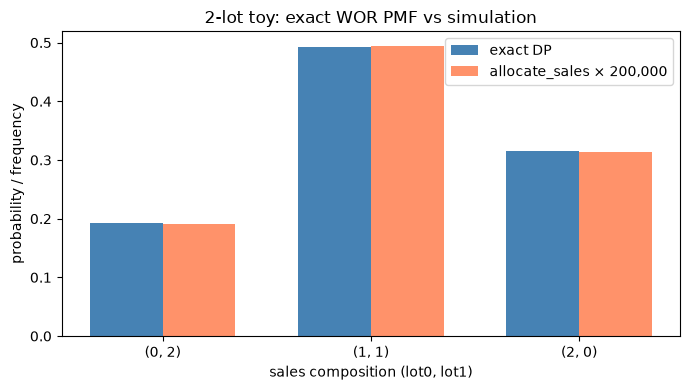

DP mass on support: 1.000000
Sim mass on support: 1.000000


In [4]:
N_SIM = 200_000
sim_counts: Counter[tuple[int, ...]] = Counter()
for _ in range(N_SIM):
    sold = allocate_sales(n, demand, w, rng)
    sim_counts[tuple(int(x) for x in sold)] += 1

sim_freq = {c: sim_counts[c] / N_SIM for c in comps}

labels = [str(c) for c in comps]
p_dp = [dp_table.get(c, 0.0) for c in comps]
p_sim = [sim_freq[c] for c in comps]

x = np.arange(len(comps))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, p_dp, width, label="exact DP", color="steelblue")
ax.bar(x + width / 2, p_sim, width, label=f"allocate_sales × {N_SIM:,}", color="coral", alpha=0.85)
ax.set_xticks(x, labels)
ax.set_xlabel("sales composition (lot0, lot1)")
ax.set_ylabel("probability / frequency")
ax.set_title("2-lot toy: exact WOR PMF vs simulation")
ax.legend()
fig.tight_layout()
plt.show()

print(f"DP mass on support: {sum(p_dp):.6f}")
print(f"Sim mass on support: {sum(p_sim):.6f}")

Fresh-biased picking (`σ < ∞`) makes `(2,0)` more likely than `(1,1)` even
though both lots have equal counts — the younger lot carries higher survival
weight. WOR coupling means `(0,2)` is **not** the mirror of `(2,0)`; after two
picks from lot 0, lot 1's relative weight changes.

## Exact P1 likelihood: sequential WOR × Binomial waste

`log_p_sales_waste_given_ages` marginalises latent per-lot sales compositions
consistent with totals `(sales_tot, waste_tot)`, then scores waste with
independent Binomial draws on remainders using `death_prob_survival_ratio`.

Stage 0 fixture: `n=(3,3)`, `τ=(1,5)`, `sales=2`, `waste=1`.

In [5]:
def hand_log_p_sales_waste_given_ages(
    n_: list[int],
    tau_: list[float],
    sales_tot: int,
    waste_tot: int,
    p: ModelParams,
) -> float:
    """Contract lock from tests/test_age_likelihood.py (pure Python WOR)."""
    on_hand = int(sum(n_))
    if sales_tot < 0 or waste_tot < 0 or sales_tot > on_hand:
        return float("-inf")
    if waste_tot > on_hand - sales_tot:
        return float("-inf")

    dtau = q10_age_increment(
        1.0,
        t_store_c=p.t_store_c,
        t_ref_c=p.t_ref_c,
        q10=p.q10,
    )
    w_ = picking_weights(
        tau_,
        sigma=p.sigma,
        beta=p.beta,
        eta=p.eta_ref,
        uniform=p.uniform_picking,
    )
    p_die = [
        death_prob_survival_ratio(t, dtau, beta=p.beta, eta=p.eta_ref) for t in tau_
    ]

    if sales_tot == on_hand:
        sales_comps = [tuple(n_)]
        sales_probs = [1.0]
    else:
        sales_comps = iter_compositions(n_, sales_tot)
        sales_probs = [
            sequential_wor_composition_prob_pure_python(n_, list(s), w_) for s in sales_comps
        ]

    like = 0.0
    for sales, p_sales in zip(sales_comps, sales_probs, strict=True):
        if p_sales <= 0.0:
            continue
        remaining = [ni - si for ni, si in zip(n_, sales, strict=True)]
        p_waste = 0.0
        for waste in iter_compositions(remaining, waste_tot):
            term = 1.0
            for wi, ri, pi in zip(waste, remaining, p_die, strict=True):
                term *= math.comb(ri, wi) * (pi**wi) * ((1.0 - pi) ** (ri - wi))
            p_waste += term
        like += p_sales * p_waste

    return float("-inf") if like <= 0.0 else float(math.log(like))


ll_hand = hand_log_p_sales_waste_given_ages(
    list(STAGE0_N), list(STAGE0_TAU_GRID), STAGE0_SALES_TOT, STAGE0_WASTE_TOT, params
)
ll_prod = log_p_sales_waste_given_ages(
    list(STAGE0_N), list(STAGE0_TAU_GRID), STAGE0_SALES_TOT, STAGE0_WASTE_TOT, params
)
print(f"hand (pure WOR) log-likelihood: {ll_hand:.8f}")
print(f"production log-likelihood:      {ll_prod:.8f}")
print(f"|Δ| = {abs(ll_hand - ll_prod):.2e}")
assert abs(ll_hand - ll_prod) < 1e-9

hand (pure WOR) log-likelihood: -1.61363339
production log-likelihood:      -1.61363339
|Δ| = 0.00e+00


In [6]:
# Decompose: which sales compositions drive the likelihood?
dtau = q10_age_increment(1.0, t_store_c=params.t_store_c, t_ref_c=params.t_ref_c, q10=params.q10)
p_die = [
    death_prob_survival_ratio(t, dtau, beta=params.beta, eta=params.eta_ref)
    for t in STAGE0_TAU_GRID
]
sales_table = sequential_wor_composition_probs(list(STAGE0_N), STAGE0_SALES_TOT, w)

print(f"{'sales':>10}  {'P(WOR)':>10}  {'P(waste|sales)':>14}  {'contribution':>12}")
for sales, p_sales in sorted(sales_table.items()):
    remaining = [ni - si for ni, si in zip(STAGE0_N, sales, strict=True)]
    p_waste = 0.0
    for waste in iter_compositions(list(remaining), STAGE0_WASTE_TOT):
        term = 1.0
        for wi, ri, pi in zip(waste, remaining, p_die, strict=True):
            term *= math.comb(ri, wi) * (pi**wi) * ((1.0 - pi) ** (ri - wi))
        p_waste += term
    print(f"{str(sales):>10}  {p_sales:10.6f}  {p_waste:14.6f}  {p_sales * p_waste:12.6f}")

     sales      P(WOR)  P(waste|sales)  contribution
    (0, 2)    0.192791        0.152101      0.029324
    (1, 1)    0.492577        0.195714      0.096404
    (2, 0)    0.314632        0.233400      0.073435


## Multinomial ablation vs exact WOR

`log_p_sales_waste_multinomial_given_ages` replaces sequential WOR with a
**with-replacement multinomial** on picking weights. ADR 0105 keeps this as an
optional diagnostic — production weights use exact WOR.

When **no cohort depletes** during sales (demand well below every count), fixed-weight
sequential WOR and multinomial agree. The ablation gap opens once a lot can sell out
mid-sequence — compare Stage 0 (no depletion) with a tight inventory case below.

In [7]:
def compare_exact_vs_multinomial(
    n_: list[int],
    tau_: list[float],
    sales_tot: int,
    waste_tot: int,
    label: str,
) -> None:
    w_ = picking_weights(
        tau_,
        sigma=params.sigma,
        beta=params.beta,
        eta=params.eta_ref,
        uniform=params.uniform_picking,
    )
    dp = sequential_wor_composition_probs(n_, sales_tot, w_)
    print(f"\n{label}: n={n_}, sales={sales_tot}, waste={waste_tot}")
    print(f"{'composition':>12}  {'WOR':>10}  {'multinomial':>12}")
    for comp in iter_compositions(n_, sales_tot):
        p_wor = dp.get(comp, 0.0)
        # multinomial sales factor only (same waste layer)
        probs = [float(x) for x in w_]
        tot = sum(probs)
        probs = [x / tot for x in probs]
        coef = math.factorial(sales_tot)
        for c in comp:
            coef //= math.factorial(c)
        p_multi = coef * math.prod(p**c for p, c in zip(probs, comp, strict=True))
        flag = "  ← depletion" if any(c == ni for c, ni in zip(comp, n_, strict=True)) else ""
        print(f"{str(comp):>12}  {p_wor:10.6f}  {p_multi:12.6f}{flag}")

    ll_e = log_p_sales_waste_given_ages(n_, tau_, sales_tot, waste_tot, params)
    ll_m = log_p_sales_waste_multinomial_given_ages(n_, tau_, sales_tot, waste_tot, params)
    print(f"log-lik exact={ll_e:.4f}  multinomial={ll_m:.4f}  Δ={ll_m - ll_e:+.4f}")


# Stage 0: generous inventory — sales PMF matches multinomial
compare_exact_vs_multinomial(
    list(STAGE0_N), list(STAGE0_TAU_GRID), STAGE0_SALES_TOT, STAGE0_WASTE_TOT, "Stage 0 (no depletion)"
)

# Tight inventory: selling 3 from (2,2) forces lot depletion
compare_exact_vs_multinomial(
    [2, 2], [1.0, 5.0], 3, 0, "Depletion case"
)


Stage 0 (no depletion): n=[3, 3], sales=2, waste=1
 composition         WOR   multinomial
      (0, 2)    0.192791      0.192791
      (1, 1)    0.492577      0.492577
      (2, 0)    0.314632      0.314632
log-lik exact=-1.6136  multinomial=-1.6136  Δ=+0.0000

Depletion case: n=[2, 2], sales=3, waste=0
 composition         WOR   multinomial
      (1, 2)    0.409072      0.324421  ← depletion
      (2, 1)    0.590928      0.414445  ← depletion
log-lik exact=-0.0651  multinomial=-0.3658  Δ=-0.3007


Multinomial **ignores depletion**: composition `(2,1)` on `n=(2,2)` is impossible
under WOR (lot 0 only has two units) but receives positive multinomial mass.
That is the structural mismatch — not a tuning parameter — and it is the same
class of error a Kalman/Gaussian observation model would introduce by smoothing
integer counts into continuous noise.

## Stockout branch

When `sales_tot == sum(n)` the shelf is cleared: the sales composition is
**deterministic** `(n₀, n₁, …)` with probability 1. Only waste on empty
remainders remains uncertain (here: zero waste when nothing is left).

Fixture from `test_metrics_helpers_and_stockout_path`: `n=(2,2)`, `sales=4`,
`waste=0`.

In [8]:
n_stock = [2, 2]
tau_stock = [1.0, 4.0]
y_stockout = P1Obs(sales_total=4, waste_total=0, arrivals=0)
prior_j = np.ones(4, dtype=float) / 4.0
prior_m = np.ones((2, 2), dtype=float) / 2.0

ll_stock = log_p_sales_waste_given_ages(n_stock, tau_stock, 4, 0, params)
print(f"stockout log-likelihood (fixed ages): {ll_stock:.6f}")

# Sales PMF collapses to n
w_stock = picking_weights(
    tau_stock,
    sigma=params.sigma,
    beta=params.beta,
    eta=params.eta_ref,
    uniform=params.uniform_picking,
)
table = sequential_wor_composition_probs(n_stock, 4, w_stock)
print(f"WOR table keys at D=4: {list(table.keys())}")
print(f"P(sales=n) = {table.get(tuple(n_stock), 0.0):.6f}")

post_j = al.exact_joint_update(n_stock, prior_j, y_stockout, params, tau_grid=tau_stock)
post_m = al.mean_field_update(n_stock, prior_m, y_stockout, params, tau_grid=tau_stock)
induced = al.induced_joint_from_marginals(post_m)

print(f"exact joint posterior (4 cells): {np.round(post_j, 4)}")
print(f"mean-field induced joint TV from exact: {al.joint_total_variation(post_j, induced):.4f}")

# Impossible demand returns -inf
ll_bad = log_p_sales_waste_given_ages(n_stock, tau_stock, sales_tot=7, waste_tot=0, params=params)
print(f"infeasible sales=7: log-lik = {ll_bad}")

stockout log-likelihood (fixed ages): 0.000000
WOR table keys at D=4: [(2, 2)]
P(sales=n) = 1.000000
exact joint posterior (4 cells): [0.25 0.25 0.25 0.25]
mean-field induced joint TV from exact: 0.0000
infeasible sales=7: log-lik = -inf


## Stage 0 exact joint update (2×2 ages)

For diagnostic completeness, compare the **exact joint** posterior on four age
cells to the hand Bayes update from `test_stage0_exact_joint_matches_hand_2x2_posterior`.

In [9]:
y_stage0 = P1Obs(
    sales_total=STAGE0_SALES_TOT,
    waste_total=STAGE0_WASTE_TOT,
    arrivals=0,
)
prior = np.ones(4, dtype=float) / 4.0

log_post = np.full(4, -np.inf, dtype=float)
for k0 in range(2):
    for k1 in range(2):
        idx = k0 * 2 + k1
        tau_cell = (STAGE0_TAU_GRID[k0], STAGE0_TAU_GRID[k1])
        ll = log_p_sales_waste_given_ages(
            list(STAGE0_N), tau_cell, STAGE0_SALES_TOT, STAGE0_WASTE_TOT, params
        )
        if math.isfinite(ll):
            log_post[idx] = math.log(0.25) + ll

m = float(np.max(log_post))
hand_post = np.exp(log_post - m)
hand_post /= hand_post.sum()

prod_post = al.exact_joint_update(
    list(STAGE0_N), prior, y_stage0, params, tau_grid=list(STAGE0_TAU_GRID)
)

tv = 0.5 * float(np.abs(hand_post - prod_post).sum())
print(f"hand posterior:       {np.round(hand_post, 4)}")
print(f"exact_joint_update:   {np.round(prod_post, 4)}")
print(f"total variation:      {tv:.2e}  (tol {TV_TOL})")
assert tv < TV_TOL

hand posterior:       [0.1331 0.26   0.26   0.3469]
exact_joint_update:   [0.1331 0.26   0.26   0.3469]
total variation:      0.00e+00  (tol 1e-09)


## Closing: the solver we actually ship

1. **Model class:** hidden Markov / state-space with compositional inventory and
   discrete age grids (ADR 0046 rung C is conceptually exact but computationally
   forbidden at scale).
2. **Observation density:** exact **sequential WOR × Binomial** — implemented
   in `sequential_wor.py` + `exact_likelihood.py`, not approximated by Normal
   noise or Kalman updates.
3. **Production solver:** Rao–Blackwellised particle filter with those exact
   weights (ADR 0046 rung A; ADR 0105 supersedes MC replay defaults).
4. **No Kalman in repo:** there is no linear-Gaussian subproblem to exploit;
   trying to force one would mis-state the picking and waste generative model.

Next notebook in the series can connect these weights to live filter steps and
particle degeneracy — here we stopped at the **likelihood** that makes the HMM
observation update honest.